In [1]:
# import block
import requests
import json
import pandas as pd
import pprint
import xml.etree.ElementTree as ET
import time
import xmltodict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import fuzz, process
import re 

**API query**

Last run date: 10.04.2026

In [ ]:
# define credentials
fs_username = "DEFINE USERNAME HERE"
fs_password = "PASTE PASSWORD HERE"

# login
login_url = "https://api.fairsharing.org/users/sign_in"
headers = {
    'Accept': 'application/json',
    'Content-Type': 'application/json'
}
payload = {
    "user": {
        "login": fs_username,
        "password": fs_password
    }
}

# send POST request
response = requests.post(login_url, headers=headers, data=json.dumps(payload))
response.raise_for_status()  # raise error if login fails

# get jwt and sacve
data = response.json()
jwt = data['jwt']
print("Login successful! JWT token received.")
print("JWT preview (first 50 chars):", jwt[:50])


records_all = []

base_url = "https://api.fairsharing.org/fairsharing_records/"

headers = {
    "Accept": "application/json",
    "Authorization": f"Bearer {jwt}"
}

page_number = 1
page_size = 100

while True:
    params = {
        "page[number]": page_number,
        "page[size]": page_size
    }

    response = requests.get(
        base_url,
        headers=headers,
        params=params
    )
    response.raise_for_status()

    data = response.json()

    records = data.get("data", [])

    if not records:
        print("No more records found.")
        break

    records_all.extend(records)

    print(f"Retrieved page {page_number}, total records so far: {len(records_all)}")

    page_number += 1

print(f"\nFinished! Total FAIRsharing records retrieved: {len(records_all)}")

print(records_all[0].keys())
pprint.pprint(records_all[0])

# save
with open("data/records_all.json", "w") as f:
    json.dump(records_all, f, indent=2)


**1. Filtering for databases**

In [3]:
with open("data/records_all.json", "r") as f:
    records_all = json.load(f)

In [4]:
databases_all = []

for rec in records_all:
        attrs = rec.get("attributes", {})

        if(attrs.get("fairsharing_registry") == "Database"):
                databases_all.append(rec)

print(F"Databases found: {len(databases_all)}")

Databases found: 3072


**2. Filtering for COVID databases with keyword search**

First, we search for the root term "cov" and the word "corona" within the metadata to capture various ways COVID-19 might be referenced. The search covers four metadata fields: domains, tags, taxonomies, and descriptions. The results are displayed below.

In [5]:
# keywords to search for
search_terms = ["cov", "corona"]

# dictionary for all unique matches
potential_filters = {
    "domains": set(),
    "user_defined_tags": set(),
    "taxonomies": set()
}

for rec in databases_all:
    attrs = rec.get("attributes", {})
    
    for field in potential_filters.keys():
        tags = attrs.get(field, [])
        if isinstance(tags, list):
            for tag in tags:
                if any(term in tag.lower() for term in search_terms):
                    potential_filters[field].add(tag)

# print results
for field, matches in potential_filters.items():
    print(f"\n--- Found in {field.upper()} ---")
    if not matches:
        print("None")
    for match in sorted(matches):
        print(match)


# check descriptions for matches
description_matches = set()

for rec in databases_all:
    desc = rec.get("attributes", {}).get("description", "")
    
    if desc:
        # split the description into individual words to find the specific match
        words = desc.lower().split()
        for word in words:
            # clean punctuation from the word 
            clean_word = "".join(char for char in word if char.isalnum() or char == '-')
            if any(term in clean_word for term in search_terms):
                description_matches.add(clean_word)

print("\n--- Found in DESCRIPTIONS ---")
if not description_matches:
    print("None")
else:
    for match in sorted(description_matches):
        print(match)


--- Found in DOMAINS ---
None

--- Found in USER_DEFINED_TAGS ---
COVID-19
Resource Discovery
acceptance of covid-19 vaccine

--- Found in TAXONOMIES ---
Circoviridae
Coronaviridae
Corticoviridae
HCoV-SARS
MERS-CoV
SARS-CoV-2
Secoviridae

--- Found in DESCRIPTIONS ---
anti-coronavirus
capacity-covid
coronal
coronavirus
coronaviruses
covalent
covariance
covdb
cover
coverage
coverages
covered
covering
covers
covid
covid-19
covid-19-related
covid-hep
covims
discover
discoverability
discoverable
discovered
discoverer
discoveries
discovering
discovery
discoverycharacterization
disscover
epicov
hcov-19
httpdiscoveryinformaticsuabedubeere
httpsenc-supportnudata-aanvraag-meerjarig-long-covid-onderzoek
land-cover
litcovid
low-coverage
mers-cov
neurodiscovery
plantscoverage
post-covid-19
recover
recoverable
recovered
sars-cov
sars-cov-2
uncover


After manually inspecting the results above, I selected only the terms actually related to COVID-19. Note that:

- the domains field returned no matches;

- the descriptions field included irrelevant hits (e.g., "discover" contains "cov" but is unrelated).

We initially search for the root "cov" as an exploratory step to capture all possible COVID-19 variations (e.g., SARS-CoV-2, MERS-CoV) without missing anything. From the results, I manually curate a final keyword list that:

- avoids false positives from unrelated "cov" matches &

- captures relevant COVID-19 word variations.

This keyword list is used for filtering in the next step.

In [6]:
covid_search_terms = {"covid", "coronavirus", "coronaviridae", "sars-cov-2", "mers-cov", "hcov-sars", "hcov-19", "2019-ncov"}

covid_databases = []

for rec in databases_all:
    attrs = rec.get("attributes", {})
    
    # collect all terms and lowercase
    tags = [t.lower() for t in (attrs.get("user_defined_tags", []) or [])]
    taxa = [t.lower() for t in (attrs.get("taxonomies", []) or [])]
    desc = (attrs.get("description", "") or "").lower()

    # is any keyword a substring of any item in this list?
    found_in_tags = any(term in tag for tag in tags for term in covid_search_terms)
    found_in_taxa = any(term in taxon for taxon in taxa for term in covid_search_terms)
    found_in_desc = any(term in desc for term in covid_search_terms)

    if found_in_tags or found_in_taxa or found_in_desc:
        covid_databases.append(rec)

print(f"Total COVID-19 repositories identified: {len(covid_databases)}")

Total COVID-19 repositories identified: 134


In [7]:
counts = {}

for rec in covid_databases:
    # Get the string value, default to 'Unknown' if missing
    rtype = rec.get("attributes", {}).get("record_type", "Unknown")
    
    # Standard dictionary counter logic
    counts[rtype] = counts.get(rtype, 0) + 1


print("Filtering with keyword search returned this many records:")
for rtype, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{rtype}: {count}")

Filtering with keyword search returned this many records:
repository: 84
knowledgebase: 37
knowledgebase_and_repository: 13


**Inspecting a single record to decide what metadata to extract**

In [8]:
pprint.pprint(covid_databases[1])

{'attributes': {'abbreviation': 'ViralZone',
                'countries': ['Switzerland'],
                'created_at': '2017-03-14T16:27:59.000Z',
                'description': 'This FAIRsharing record describes: ViralZone '
                               'is a web resource for viral genes and '
                               'families, providing detailed molecular and '
                               'epidemiological information, along with virion '
                               'and genome figures. Each virus or family page '
                               'gives easy access to UniProtKB/Swiss-Prot '
                               'viral protein entries.',
                'doi': '10.25504/FAIRsharing.tppk10',
                'domains': ['gene expression',
                            'host',
                            'gene',
                            'genome',
                            'viral sequence'],
                'exhaustive_licences': False,
                'fairshar

**Extracting metadata and creating a dataframe of identified COVID-related databases**

In [9]:
rows = []

for item in covid_databases:
    # Handle similarity-wrapped or direct objects
    rec = item['repo'] if isinstance(item, dict) and 'repo' in item else item
    
    attrs = rec.get("attributes", {})
    meta = attrs.get("metadata", {})
    
    # funders: look for items where the relation is 'funds'
    grants_list = attrs.get("grants", [])
    funder_names = []
    funder_types = []
    for g in grants_list:
        state = g.get("saved_state", {})
        if state.get("relation") == "funds":
            funder_names.append(state.get("name", "N/A"))
            funder_types.append(", ".join(state.get("types", [])))

    # maintainers: look for items where the relation is 'maintains'
    maintainers_list = attrs.get("grants", [])
    maintaining_names = []
    maintaining_types = []
    for g in maintainers_list:
        state = g.get("saved_state", {})
        if state.get("relation") == "maintains":
            maintaining_names.append(state.get("name", "N/A"))
            maintaining_types.append(", ".join(state.get("types", [])))
            
    # publications: look for dois only
    pubs_list = attrs.get("publications", [])
    dois = [p.get("doi") for p in pubs_list if p.get("doi")]

    # contacts: name and email
    contacts_list = meta.get("contacts", [])
    c_names = [c.get('contact_name') for c in contacts_list if c.get('contact_name')]
    c_emails = [c.get('contact_email') for c in contacts_list if c.get('contact_email')]

    row = {
        "name": meta.get("name"),
        "abbreviation": attrs.get("abbreviation"),
        "url": meta.get("homepage"),
        "id": rec.get("id"),
        "description": meta.get("description"),
        "status": meta.get("status"),
        "record_type": attrs.get("record_type"),
        "countries": ", ".join(attrs.get("countries", [])) if attrs.get("countries") else None,
        "year_created": meta.get("year_creation"),
        "funder": "; ".join(funder_names) if funder_names else None,
        "funder_type": "; ".join(set(funder_types)) if funder_types else None, # set() removes duplicates
        "maintaining_institution": "; ".join(maintaining_names) if maintaining_names else None,
        "maintaining_type": "; ".join(set(maintaining_types)) if maintaining_types else None,
        "contact_name": "; ".join(c_names) if c_names else None,
        "contact_email": "; ".join(c_emails) if c_emails else None,
        "data_access_condition": (meta.get("data_access_condition") or {}).get("type"),
        "data_deposition_condition": (meta.get("data_deposition_condition") or {}).get("type"),
        "publications": "; ".join(dois) if dois else None
    }

    rows.append(row)

# Create the DataFrame
df_covid = pd.DataFrame(rows)

# fix year problem
if 'year_created' in df_covid.columns:
    df_covid['year_created'] = (
        pd.to_numeric(df_covid['year_created'], errors='coerce')
        .fillna(0)
        .astype(int)
        .replace(0, "")
    )

# sort alphabetically by a column
df_covid = df_covid.sort_values(by='name', ignore_index=True)


In [10]:
df_covid.head(10)

,name,abbreviation,url,id,description,status,record_type,countries,year_created,funder,funder_type,maintaining_institution,maintaining_type,contact_name,contact_email,data_access_condition,data_deposition_condition,publications
0,COVID-19 Data Repository,None,https://www.openicpsr.org/openicpsr/covid19,4074,The COVID-19 Data Repository is a repository f...,ready,repository,United States,2022,None,None,"Regents of the University of Michigan, USA",Undefined,None,None,open,open,None
1,AccessClinicalData@NIAID,None,https://accessclinicaldata.niaid.nih.gov/,5584,AccessClinicalData@NIAID is a NIAID cloud-base...,ready,repository,United States,,National Institutes of Health,Government body,National Institute of Allergy and Infectious D...,Government body,None,None,controlled,open,None
2,Addgene,Addgene,https://www.addgene.org/,1738,Addgene is a non-profit plasmid repository ded...,ready,repository,"United Kingdom, United States",2004,Addgene,Company,Addgene,Company,General Contact Email,info@addgene.org,open,open,10.1038/nbt.2177; 10.1038/505272a; 10.1093/nar...
3,Alliance of Genome Resources,None,https://www.alliancegenome.org,2530,The primary mission of the Alliance of Genome ...,ready,knowledgebase,"United Kingdom, United States",2017,National Human Genome Research Institute (NHGR...,Government body,Alliance of Genome Resources Consortium,Consortium,General Contact,help@alliancegenome.org,open,not applicable,10.1093/nar/gkz813; 10.1534/genetics.119.302523
4,American Society of Clinical Oncology (ASCO) S...,ASCO Registry,https://old-prod.asco.org/covid-resources/asco...,3223,The American Society of Clinical Oncology (ASC...,deprecated,repository,United States,2020,None,None,"American Society of Clinical Oncology, USA",Consortium,General contact,CENTRA@asco.org,partially open,not applicable,None
5,Antibody Registry,None,https://antibodyregistry.org/,1725,The Antibody Registry exists to give researche...,ready,repository,United States,2009,National Institutes of Health (NIH) Blueprint ...,Government body,Neuroscience Information Framework (NIF),Consortium,Anita Bandrowski,abandrowski@ucsd.edu,open,open,10.1038/nmeth.2570; 10.1093/nar/gkac927
6,Arca Dados,None,https://arcadados.fiocruz.br/,5829,Arca Dados is Fiocruz's official research data...,ready,repository,Brazil,2019,None,None,Fundação Oswaldo Cruz,Government body,Vanessa Jorge,vanessa.jorge@fiocruz.br,partially open,controlled,None
7,BBMRI-ERIC Directory,None,https://directory.bbmri-eric.eu/,2857,The BBMRI-ERIC Directory is a tool to share ag...,ready,repository,"Austria, Belgium, Bulgaria, Cyprus, Czech Repu...",2015,None,None,"BBMRI-ERIC national nodes, Graz, Austria; BBMR...",Undefined; Consortium,Petr Holub,petr.holub@bbmri-eric.eu,open,controlled,10.1089/bio.2016.0088
8,Better Outcomes Registry & Network,BORN Ontario,https://www.bornontario.ca/en/index.aspx,4061,"Funded by the Government of Ontario, the Bette...",ready,repository,Canada,2020,None,None,Children's Hospital of Eastern Ontario,Government body,COVID Inquiries; General Inquiries,covid@bornontario.ca; info@bornontario.ca,controlled,open,None
9,BioData.pt Data Management Portal,DMPortal,https://dmportal.biodata.pt/,4475,The BioData.pt Data Management Portal (DMPorta...,ready,repository,Portugal,2020,None,None,BioData.pt,Consortium,DMPortal Team,dmportal@biodata.pt,open,open,None


In [11]:
# save df in output folder
df_covid.to_csv("data/covid_databases.csv", index=False)

**3. Look for more databases with similarity approach**

To capture COVID-19 databases that our keyword search might miss, we use a similarity-based approach. The idea is to find repositories that are semantically similar to the COVID-19 databases we already identified (via keywords). This comparison is done programmatically across multiple metadata fields.

The method works as follows:

**1. The metadata "soup":**

Instead of looking at subjects, tags, or domains separately, we combine all of the information for each repository into one block of text = like a soup.


**2. Identifying the "important" words:**

Not all words are equally useful or informative. For example, the subject "epidemiology" appears a lot but it's a very broad category and so it might not help distinguishing one repository from another. So we give the terms "weights" in a way that common words are downplayed and rare/ specific terms are highlighted. Specific method: TF-IDF.

**3. Building a "gold standard" COVID repository:**

We then look at the 84 COVID repositories that we already successfully identified and "take their average" to represent what a typical COVID repository would look like, thereby creating something like a mathematical gold standard.

**4. Similarity scoring**

Finally, we compare every repository in the database to the "gold standard" profile. This gives us similarity scores between 0 (nothing in common) and 1 (perfect match). Specific method: cosine similarity.

In [12]:
def create_soup(rec):
    attrs = rec.get("attributes", {})
    
    
    subjects = " ".join(attrs.get("subjects", []))
    tags = " ".join(attrs.get("user_defined_tags", []))
    domains = " ".join(attrs.get("domains", []))
    taxonomies = " ".join(attrs.get("taxonomies", []))
    
    # combine
    soup = f"{subjects} {tags} {domains} {taxonomies}"

    return " ".join(soup.lower().split())

# create a list of "soups" for ALL 3072 databases
all_soups = [create_soup(r) for r in databases_all]

In [13]:
# 1. turn repos into vectors (TF-IDF)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(all_soups)

# 2. identify the indices of the 84 known COVID repos
covid_ids = [r['id'] for r in covid_databases] 
all_ids = [r['id'] for r in databases_all]
covid_indices = [all_ids.index(cid) for cid in covid_ids]

# 3. calculate 'centroid' (the average vector of COVID repos)
covid_vectors = tfidf_matrix[covid_indices]
centroid = np.asarray(covid_vectors.mean(axis=0))

# 4. calculate similarity of EVERY repo to that COVID centroid
similarities = cosine_similarity(tfidf_matrix, centroid).flatten()

# 5. attach the scores and filter out the ones we already know
cosine_results = []
for i, score in enumerate(similarities):
    if i not in covid_indices:
        cosine_results.append({
            'repo': databases_all[i],
            'similarity_score': score
        })

# sort by highest similarity
cosine_results = sorted(cosine_results, key=lambda x: x['similarity_score'], reverse=True)

In [14]:
# convert to df for convenience
df_cosine_results = pd.DataFrame(cosine_results)
df_cosine_results.head()

,repo,similarity_score
0,"{'id': '7386', 'type': 'fairsharing_records', ...",0.410045
1,"{'id': '2719', 'type': 'fairsharing_records', ...",0.406009
2,"{'id': '7062', 'type': 'fairsharing_records', ...",0.398216
3,"{'id': '2928', 'type': 'fairsharing_records', ...",0.387687
4,"{'id': '2927', 'type': 'fairsharing_records', ...",0.381429


--- Score statistics ---
count    2938.000000
mean        0.069068
std         0.058502
min         0.000000
25%         0.027628
50%         0.052669
75%         0.091844
max         0.410045
Name: similarity_score, dtype: float64


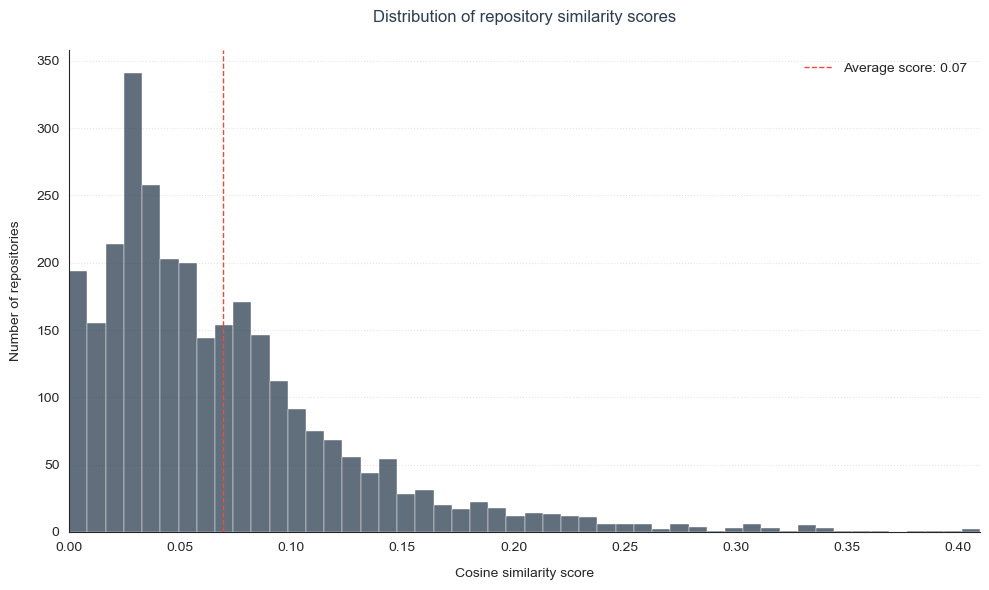

In [16]:
# get basic stats
print("--- Score statistics ---")
print(df_cosine_results['similarity_score'].describe())

# visualize distribution 
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_cosine_results['similarity_score'], bins=50, color="#2c3e50", edgecolor="white", linewidth=0.3, ax=ax)
ax.margins(x=0)

# mean line
mean_val = df_cosine_results['similarity_score'].mean()
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1, label=f'Average score: {mean_val:.2f}')

sns.despine()

# font weights and titles
plt.title('Distribution of repository similarity scores', fontsize=12, pad=20, color='#2c3e50')
plt.xlabel('Cosine similarity score', fontsize=10, labelpad=10)
plt.ylabel('Number of repositories', fontsize=10, labelpad=10)

# legend and grid
plt.legend(frameon=False, fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [17]:
# extract similarity scores
scores = np.array([r['similarity_score'] for r in cosine_results])

cuts = {
    "top 5%": 0.95,
    "top 10%": 0.90,
    "top 20%": 0.80,
}

rows = []
for label, p in cuts.items():
    thr = np.quantile(scores, p)
    n = (scores >= thr).sum()
    rows.append({
        "band": label,
        "percentile": p,
        "threshold_score": thr,
        "n_candidates": int(n)
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df)

      band  percentile  threshold_score  n_candidates
0   top 5%        0.95         0.184223           147
1  top 10%        0.90         0.141428           294
2  top 20%        0.80         0.103604           588


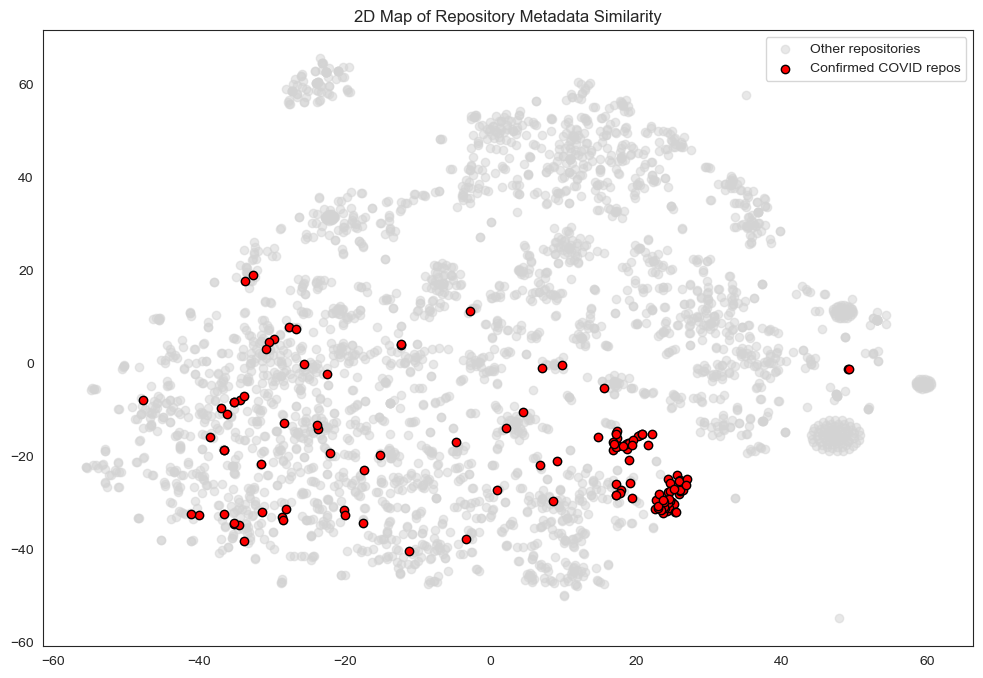

In [18]:
# reduce TF-IDF matrix to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
vis_dims = tsne.fit_transform(tfidf_matrix.toarray())

# seperate coordinates
x = vis_dims[:, 0]
y = vis_dims[:, 1]

# plot
plt.figure(figsize=(12, 8))
plt.scatter(x, y, c='lightgrey', alpha=0.5, label='Other repositories') # all repos in light gray
plt.scatter(x[covid_indices], y[covid_indices], c='red', edgecolors='black', label='Confirmed COVID repos') # covid repos in red
plt.title('2D Map of Repository Metadata Similarity')
plt.legend()

plt.show()

In [19]:
# thresholds
scores = np.array([r['similarity_score'] for r in cosine_results])
thr_10 = np.quantile(scores, 0.90)
thr_5 = np.quantile(scores, 0.95)

# filter to top 10%
top_results = [r for r in cosine_results if r['similarity_score'] >= thr_10]

rows = []

for item in top_results:
    rec = item['repo']
    score = item['similarity_score']

    attrs = rec.get("attributes", {})
    meta = attrs.get("metadata", {})

    grants_list = attrs.get("grants", [])
    funder_names = []
    funder_types = []
    for g in grants_list:
        state = g.get("saved_state", {})
        if state.get("relation") == "funds":
            funder_names.append(state.get("name", "N/A"))
            funder_types.append(", ".join(state.get("types", [])))

    maintainers_list = attrs.get("grants", [])
    maintaining_names = []
    maintaining_types = []
    for g in maintainers_list:
        state = g.get("saved_state", {})
        if state.get("relation") == "maintains":
            maintaining_names.append(state.get("name", "N/A"))
            maintaining_types.append(", ".join(state.get("types", [])))

    pubs_list = attrs.get("publications", [])
    dois = [p.get("doi") for p in pubs_list if p.get("doi")]

    contacts_list = meta.get("contacts", [])
    c_names = [c.get('contact_name') for c in contacts_list if c.get('contact_name')]
    c_emails = [c.get('contact_email') for c in contacts_list if c.get('contact_email')]

    row = {
        "name": meta.get("name"),
        "abbreviation": attrs.get("abbreviation"),
        "url": meta.get("homepage"),
        "id": rec.get("id"),
        "description": meta.get("description"),
        "status": meta.get("status"),
        "record_type": attrs.get("record_type"),
        "countries": ", ".join(attrs.get("countries", [])) if attrs.get("countries") else None,
        "year_created": meta.get("year_creation"),
        "funder": "; ".join(funder_names) if funder_names else None,
        "funder_type": "; ".join(set(funder_types)) if funder_types else None,
        "maintaining_institution": "; ".join(maintaining_names) if maintaining_names else None,
        "maintaining_type": "; ".join(set(maintaining_types)) if maintaining_types else None,
        "contact_name": "; ".join(c_names) if c_names else None,
        "contact_email": "; ".join(c_emails) if c_emails else None,
        "data_access_condition": (meta.get("data_access_condition") or {}).get("type"),
        "data_deposition_condition": (meta.get("data_deposition_condition") or {}).get("type"),
        "publications": "; ".join(dois) if dois else None,
        "similarity_score": score,
        "percentile": "top 5%" if score >= thr_5 else "top 10%"
    }

    rows.append(row)

df_top_similarity = pd.DataFrame(rows)

if 'year_created' in df_top_similarity.columns:
    df_top_similarity['year_created'] = (
        pd.to_numeric(df_top_similarity['year_created'], errors='coerce')
        .fillna(0)
        .astype(int)
        .replace(0, "")
    )

df_top_similarity = df_top_similarity.sort_values(
    by="similarity_score",
    ascending=False,
    ignore_index=True
)

In [20]:
df_top_similarity.head(10)

,name,abbreviation,url,id,description,status,record_type,countries,year_created,funder,funder_type,maintaining_institution,maintaining_type,contact_name,contact_email,data_access_condition,data_deposition_condition,publications,similarity_score,percentile
0,German Portal for Medical Research Data,FDPG,https://forschen-fuer-gesundheit.de/,7386,The FDPG is the German Portal for Medical Rese...,ready,repository,Germany,,Federal Ministry of Education and Research,Government body,Medical Informatics Initiative,Consortium,General Contact,info@forschen-fuer-gesundheit.de,controlled,open,None,0.410045,top 5%
1,Vivli,Vivli,https://vivli.org/,2719,The Vivli data repository provides a global da...,ready,repository,Worldwide,2018,"Laura and John Arnold Foundation, USA; Lyda Hi...",Company; Charitable foundation,Multi-Regional Clinical Trials Center of Brigh...,Research institute,Julie Wood,jwood@vivli.org,controlled,controlled,None,0.406009,top 5%
2,HUNT Databank,None,https://hunt-db.medisin.ntnu.no/hunt-db/,7062,HUNT Databank is a research database hosted by...,ready,repository,Norway,,None,None,NTNU - Norwegian University of Science and Tec...,University,General Contact,kontakt@hunt.ntnu.no,open,not applicable,None,0.398216,top 5%
3,International Traditional Medicine Clinical Tr...,ISRCTN Registry,http://www.isrctn.com/,2928,The ISRCTN registry is a primary clinical tria...,ready,repository,United Kingdom,2000,Medical Research Council; Department of Health...,Government body; Charitable foundation,ISRCTN; Springer Nature,Publisher; Company,None,None,open,controlled,None,0.387687,top 5%
4,Australian New Zealand Clinical Trials Registry,ANZCTR,http://www.anzctr.org.au/,2927,The Australian New Zealand Clinical Trials Reg...,ready,repository,"Australia, New Zealand",,National Collaborative Research Infrastructure...,Government body,NHMRC Clinical Trials Centre,Research institute,None,None,open,open,None,0.381429,top 5%
5,UMIN Clinical Trials Registry,UMIN-CTR,https://www.umin.ac.jp/ctr/index.htm,2931,UMIN-CTR is a Clinical Trials Registry hosted ...,ready,repository,Japan,1989,"Ministry of Education, Culture, Sports, Scienc...",Government body,University Hospital Medical Information Network,Consortium,None,None,open,controlled,None,0.363759,top 5%
6,Models of Infectious Disease Agent Study Catalog,MIDAS Catalog,https://catalog.midasnetwork.us,5867,The MIDAS Catalog is a web-based platform host...,ready,knowledgebase,United States,2021,National Institute of General Medical Sciences,Government body,MIDAS Coordination Center (MCC); University of...,University; Consortium,General Contact,questions@midasnetwork.us,open,not applicable,None,0.357298,top 5%
7,Clinical Trials Information System,CTIS,https://euclinicaltrials.eu/,4990,The Clinical Trials Information System (CTIS) ...,ready,repository,European Union,2022,None,None,"European Medicines Agency, London, UK",Government body,General Website Information,ct.communication@ema.europa.eu,open,controlled,None,0.348813,top 5%
8,Overview of Medical Research in the Netherlands,OMON,https://onderzoekmetmensen.nl/en,2932,The Overview of Medical Research in the Nether...,ready,repository,Netherlands,2022,None,None,Central Committee on Research Involving Human...,Government body,OMON CCMO,omon@ccmo.nl,open,controlled,None,0.337287,top 5%
9,HealthData.gov,HealthData.gov,https://www.healthdata.gov/,2246,HealthData.gov makes high value health data mo...,ready,knowledgebase_and_repository,United States,2010,None,None,United States Department of Health and Human S...,Government body,General Enquiries,HealthData@HHS.gov,open,not applicable,None,0.337095,top 5%


In [21]:
# double check that there's no overlap between the two dfs
overlap_ids = set(df_covid["id"]) & set(df_top_similarity["id"])
print(overlap_ids)

set()


In [22]:
df_top_similarity.to_csv("data/similar_databases.csv", index=False)

**Looking for databases that are linked**

Checking two relations:
1. "**shares data with**" - it means: "This database shares a portion of data with another database. This relation does not specify if the data being shared is from the resource you are editing, the resource being linked, or a combination of both."


2. "**extends**" - it means: "This is our most generic database -> database relationship. Useful when your resource extends a database, but other more precise relationships (shares_code_with, shares_data_with) are not suitable."

In [23]:
shares_links = []
extends_links = []

for item in covid_databases:
    rec = item['repo'] if isinstance(item, dict) and 'repo' in item else item
    attrs = rec.get("attributes", {})
    
    linking_records = attrs.get("linking_records", [])
    
    for link in linking_records:
        relation = link.get("relation")
        
        source_name = (
            attrs.get("metadata", {}).get("name")
            or attrs.get("abbreviation")
            or rec.get("name")
            or rec.get("id")
        )
        
        link_info = {
            "source_db_id": rec.get("id"),
            "source_db_name": source_name,
            "linked_db_id": link.get("linking_record_id"),
            "linked_db_name": link.get("linking_record_name"),
            "linked_db_registry": link.get("linking_record_registry"),
            "linked_db_type": link.get("linking_record_type"),
            "relation": relation,
        }
        
        if relation == "shares_data_with":
            shares_links.append(link_info)
        elif relation == "extends":
            extends_links.append(link_info)

print(f"Number of 'shares_data_with' links found: {len(shares_links)}")
print(f"Number of 'extends' links found: {len(extends_links)}")

print("\n--- shares_data_with links ---")
for link in shares_links:
    print(link)

print("\n--- extends links ---")
for link in extends_links:
    print(link)

Number of 'shares_data_with' links found: 0
Number of 'extends' links found: 0

--- shares_data_with links ---

--- extends links ---


**DEDUPLICATING (Google sheet)**

In [25]:
# read csv
google_sheet = pd.read_csv(
    "../COVID_google_sheet.csv",
    skiprows=1,  # skip row 1, so row 2 becomes the header
    usecols=["Acronym", "Full name"],  # keep only these columns
)

# drop rows where BOTH Acronym and Full name are empty/NaN
google_sheet = google_sheet.dropna(subset=["Acronym", "Full name"], thresh=1)

# clean up whitespace
google_sheet["Acronym"] = google_sheet["Acronym"].str.strip()
google_sheet["Full name"] = google_sheet["Full name"].str.strip()

In [26]:
print(f"Number of rows after cleaning: {len(google_sheet)}")
google_sheet.head(10)

Number of rows after cleaning: 487


,Acronym,Full name
0,AAOS Registry Program (includes American Joint...,American Academy of Orthopaedic Surgeons
1,ACR CIRR,American College of Radiology COVID-19 Imaging...
2,ACS COVID-19 Registry (also called COVID-ACS),American College of Surgeons COVID-19 Registry
3,COVID-ACS Registry,COVID-Acute Coronary Syndrome Registry
4,AGMT COVID-19 Registry,Austrian COVID-19 Registry
5,ASH Research Collaborative COVID-19 Registry f...,American Society for Hematology Research Colla...
6,ASCO Registry,American Society of Clinical Oncology Survey o...
7,B1MG and 1+MG,1 Million Genomes & Beyond 1 Million Genomes P...
8,BADBIR,British Association of Dermatologists Biologic...
9,BEAT19,"Behavior, Environment and Treatments for COVID..."


**Method for deduplication**

step 1: build a bag of all names from google sheet. this includes: the acronym column (e.g., "ASCO Registry"), the Full name column (e.g., "American Society of Clinical Oncology"), and any extracted acronym from parentheses (e.g., from "ACS COVID-19 Registry (also called COVID-ACS)" → extracts "COVID-ACS")

step 2: check for duplicates for each name & abbreviation against the entire bag of google sheets names, which includes checking for:

    - exact matches
    - substring matches (e.g. if "asco" is in "asco registry" → return True)
    - fuzzy matches (based on similarity scores)
-> this is the is_duplicate function - we then apply this function to both dfs (covid and similarity dfs)

*fuzzy matches: compares the name & acronym from the dfs against the google sheet bag of words, calculates a similarity score for each comaprison, takes the best (highest) score, if best score ≥ 80 → return True (duplicate)

In [27]:
# copy the DataFrames to avoid modifying originals
df_covid_dedup = df_covid.copy()
df_top_similarity_dedup = df_top_similarity.copy()

# create normalized name columns for matching
df_covid_dedup['_normalized_name'] = df_covid_dedup['name'].str.lower().str.strip()
df_top_similarity_dedup['_normalized_name'] = df_top_similarity_dedup['name'].str.lower().str.strip()
google_sheet['_normalized_acronym'] = google_sheet['Acronym'].str.lower().str.strip()
google_sheet['_normalized_fullname'] = google_sheet['Full name'].str.lower().str.strip()

# function to extract acronym from parentheses
def extract_parenthesis_acronym(text):
    if pd.isna(text):
        return None
    match = re.search(r'\(([^()]+)\)', str(text))
    if match:
        inner = match.group(1).strip()
        # If it looks like an acronym (mostly uppercase/short)
        if len(inner) <= 20 and inner.upper() == inner:
            return inner.lower()
    return None

google_sheet['_extracted_acronym'] = google_sheet['Acronym'].apply(extract_parenthesis_acronym)

# Build a combined list of possible names from google_sheet
google_names = []
for _, row in google_sheet.iterrows():
    names_to_check = []
    if pd.notna(row['Acronym']) and str(row['Acronym']).strip():
        names_to_check.append(str(row['Acronym']).lower().strip())
    if pd.notna(row['Full name']) and str(row['Full name']).strip():
        names_to_check.append(str(row['Full name']).lower().strip())
    if pd.notna(row['_extracted_acronym']) and str(row['_extracted_acronym']).strip():
        names_to_check.append(str(row['_extracted_acronym']).lower().strip())
    google_names.extend(names_to_check)

google_names = list(set(google_names))  # unique

# Function to check if a name is a duplicate
def is_duplicate(row, threshold=80):
    """check if either name OR abbreviation matches google sheet"""
    # get values to check
    values_to_check = [row['name']]
    if 'abbreviation' in row.index and pd.notna(row['abbreviation']):
        values_to_check.append(row['abbreviation'])
    # check each value
    for value in values_to_check:
        if pd.isna(value):
            continue
        value_lower = str(value).lower().strip()
        # exact match
        if value_lower in google_names:
            return True
        # substring match
        for google_name in google_names:
            if len(google_name) >= 3:  # Only check substrings of 3+ characters
                if google_name in value_lower or value_lower in google_name:
                    return True
        # fuzzy match
        best_score = max([fuzz.ratio(value_lower, google_name) for google_name in google_names], default=0)
        if best_score >= threshold:
            return True
    
    return False

# apply function to both dfs
df_covid_dedup['_is_duplicate'] = df_covid_dedup.apply(is_duplicate, axis=1)
df_top_similarity_dedup['_is_duplicate'] = df_top_similarity_dedup.apply(is_duplicate, axis=1)

In [ ]:
print("\n=== Duplicates found in COVID df ===")
covid_duplicates = df_covid_dedup[df_covid_dedup['_is_duplicate']]
print(f"Total: {len(covid_duplicates)} duplicates found out of {len(df_covid)} covid databases\n")

covid_duplicates[['name', 'abbreviation', '_is_duplicate']]


=== Duplicates found in COVID df ===
Total: 54 duplicates found out of 134 covid databases



,name,abbreviation,_is_duplicate
0,COVID-19 Data Repository,None,True
4,American Society of Clinical Oncology (ASCO) S...,ASCO Registry,True
8,Better Outcomes Registry & Network,BORN Ontario,True
16,British Association of Dermatologists Biologic...,BADBIR,True
18,COVID-19 CVD Registry,None,True
19,COVID-19 Data Index,None,True
20,COVID-19 Data Portal,None,True
21,COVID-19 Data Portal Spain,None,True
22,COVID-19 Dermatology registry,None,True
24,COVID-19 Global Rheumatology Alliance,None,True


In [29]:
print("\n=== Duplicates found in Top Similarity df ===")
similarity_duplicates = df_top_similarity_dedup[df_top_similarity_dedup['_is_duplicate']]
print(f"Total: {len(similarity_duplicates)} duplicates\n")
similarity_duplicates[['name', 'abbreviation', '_is_duplicate', 'similarity_score']]


=== Duplicates found in Top Similarity df ===
Total: 53 duplicates



,name,abbreviation,_is_duplicate,similarity_score
1,Vivli,Vivli,True,0.406009
3,International Traditional Medicine Clinical Tr...,ISRCTN Registry,True,0.387687
8,Overview of Medical Research in the Netherlands,OMON,True,0.337287
12,National Institute of Mental Health Data Archive,NDA,True,0.334555
17,Medical Information Mart for Intensive Care III,MIMIC-III,True,0.319815
21,Global Initiative on Sharing Avian Influenza Data,GISAID,True,0.310563
30,AD Knowledge Portal,None,True,0.286604
34,The NIAID Data Ecosystem Discovery Portal,NDE,True,0.278276
40,NICHD Data and Specimen Hub,NICHD DASH,True,0.270424
41,ClinVar,ClinVar,True,0.263029


In [ ]:
# concat the two duplicate dfs
covid_duplicates['filter_approach'] = 'keyword'
similarity_duplicates['filter_approach'] = 'similarity'

merged_duplicates = pd.concat([covid_duplicates, similarity_duplicates], ignore_index=True)

/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_66872/4008100644.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid_duplicates['filter_approach'] = 'keyword'
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_66872/4008100644.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_duplicates['filter_approach'] = 'similarity'


In [40]:
print(merged_duplicates.columns.tolist())
merged_duplicates.head()

['name', 'abbreviation', 'url', 'id', 'description', 'status', 'record_type', 'countries', 'year_created', 'funder', 'funder_type', 'maintaining_institution', 'maintaining_type', 'contact_name', 'contact_email', 'data_access_condition', 'data_deposition_condition', 'publications', '_normalized_name', '_is_duplicate', 'filter_approach', 'similarity_score', 'percentile']


,name,abbreviation,url,id,description,status,record_type,countries,year_created,funder,...,contact_name,contact_email,data_access_condition,data_deposition_condition,publications,_normalized_name,_is_duplicate,filter_approach,similarity_score,percentile
0,COVID-19 Data Repository,None,https://www.openicpsr.org/openicpsr/covid19,4074,The COVID-19 Data Repository is a repository f...,ready,repository,United States,2022,None,...,None,None,open,open,None,covid-19 data repository,True,keyword,NaN,NaN
1,American Society of Clinical Oncology (ASCO) S...,ASCO Registry,https://old-prod.asco.org/covid-resources/asco...,3223,The American Society of Clinical Oncology (ASC...,deprecated,repository,United States,2020,None,...,General contact,CENTRA@asco.org,partially open,not applicable,None,american society of clinical oncology (asco) s...,True,keyword,NaN,NaN
2,Better Outcomes Registry & Network,BORN Ontario,https://www.bornontario.ca/en/index.aspx,4061,"Funded by the Government of Ontario, the Bette...",ready,repository,Canada,2020,None,...,COVID Inquiries; General Inquiries,covid@bornontario.ca; info@bornontario.ca,controlled,open,None,better outcomes registry & network,True,keyword,NaN,NaN
3,British Association of Dermatologists Biologic...,BADBIR,http://www.badbir.org/,4060,British Association of Dermatologists Biologic...,ready,repository,"Ireland, United Kingdom",2011,None,...,General contact,badbir@manchester.ac.uk,controlled,controlled,10.1111/j.1365-2133.2012.10835.x,british association of dermatologists biologic...,True,keyword,NaN,NaN
4,COVID-19 CVD Registry,None,https://www.heart.org/en/professional/quality-...,3244,"As physicians, scientists and researchers worl...",ready,repository,United States,2020,None,...,General contact,qualityresearch@heart.org,controlled,controlled,None,covid-19 cvd registry,True,keyword,NaN,NaN


In [43]:
# export duplicates df as csv
merged_duplicates.to_csv("output/duplicates_all.csv", index=False)

/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_66872/1538125298.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_temp.groupby('score_bin').agg(
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_66872/1538125298.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_66872/1538125298.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)


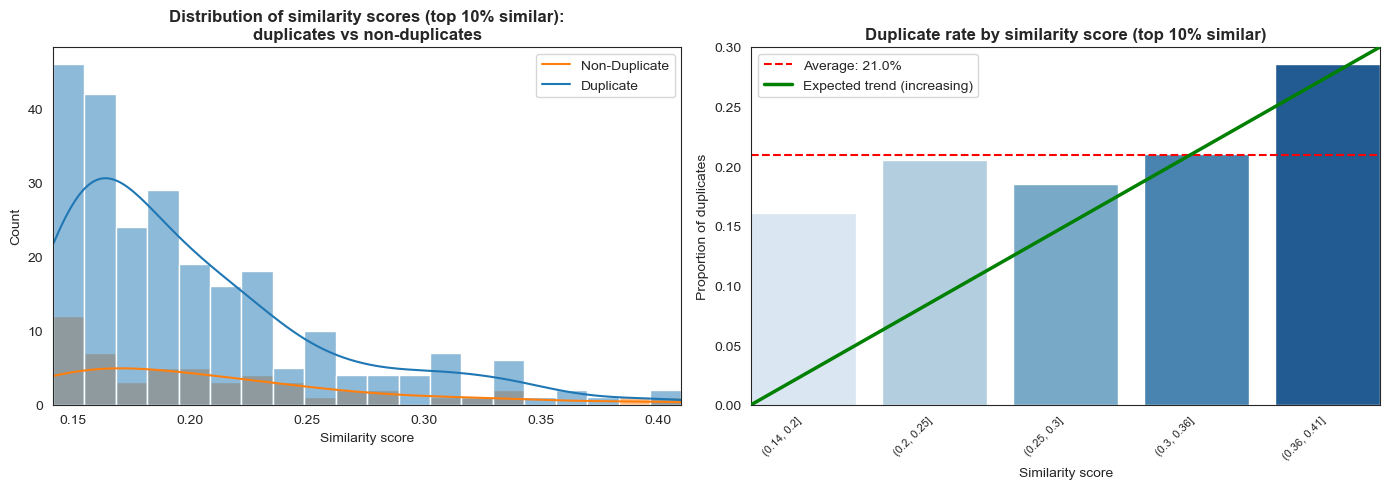


=== Summary ===
Total rows: 294
Duplicates: 53 (18.0%)
Non-duplicates: 241 (82.0%)

Score range: 0.142 to 0.410


In [ ]:
# temporary copy to mark duplicates
df_temp = df_top_similarity.copy()
df_temp['_is_duplicate'] = df_temp.apply(is_duplicate, axis=1)


# create the plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution
sns.histplot(
    data=df_temp,
    x='similarity_score',
    hue='_is_duplicate',
    bins=20,
    alpha=0.5,
    ax=axes[0],
    kde=True
)
axes[0].margins(x=0)
axes[0].set_title('Distribution of similarity scores (top 10% similar):\nduplicates vs non-duplicates', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Similarity score')
axes[0].set_ylabel('Count')
axes[0].legend(['Non-Duplicate', 'Duplicate'])

# Plot 2: Duplicate rate by bin
df_temp['score_bin'] = pd.cut(df_temp['similarity_score'], bins=5, precision=2)
bin_stats = df_temp.groupby('score_bin').agg(
    total_count=('_is_duplicate', 'count'),
    duplicate_rate=('_is_duplicate', 'mean')
).reset_index()

sns.barplot(
    data=bin_stats,
    x='score_bin',
    y='duplicate_rate',
    ax=axes[1],
    palette='Blues'
)

axes[1].margins(x=0)  # remove horizontal padding
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1].set_title('Duplicate rate by similarity score (top 10% similar)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Similarity score')
axes[1].set_ylabel('Proportion of duplicates')

# add average line
axes[1].axhline(y=bin_stats['duplicate_rate'].mean(), color='red', linestyle='--', 
                label=f'Average: {bin_stats["duplicate_rate"].mean():.1%}')

# add diagonal line from bottom-left to top-right for "ideal"
axes[1].plot([0, 1], [0, 1], color='green', linestyle='-', linewidth=2.5, 
             transform=axes[1].transAxes, label='Expected trend (increasing)', zorder=5)
axes[1].legend()

plt.tight_layout()
plt.savefig('output/similarity_score_duplicates_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# summary
print(f"\n=== Summary ===")
print(f"Total rows: {len(df_temp)}")
print(f"Duplicates: {df_temp['_is_duplicate'].sum()} ({df_temp['_is_duplicate'].mean():.1%})")
print(f"Non-duplicates: {(~df_temp['_is_duplicate']).sum()} ({(~df_temp['_is_duplicate']).mean():.1%})")
print(f"\nScore range: {df_temp['similarity_score'].min():.3f} to {df_temp['similarity_score'].max():.3f}")

In [42]:
# remove duplicates
df_covid_dedup = df_covid_dedup[~df_covid_dedup['_is_duplicate']].drop(columns=['_is_duplicate']).reset_index(drop=True)
df_top_similarity_dedup = df_top_similarity_dedup[~df_top_similarity_dedup['_is_duplicate']].drop(columns=['_is_duplicate']).reset_index(drop=True)

print(f"\nCOVID df: {len(df_covid)} → {len(df_covid_dedup)} rows after dedup")
print(f"Top similarity df: {len(df_top_similarity)} → {len(df_top_similarity_dedup)} rows after dedup")


COVID df: 134 → 80 rows after dedup
Top similarity df: 294 → 241 rows after dedup


In [44]:
# export as csvs

df_covid_dedup.to_csv("output/covid_dedup.csv", index=False)
df_top_similarity_dedup.to_csv("output/top_similarity_dedup.csv", index=False)

In [31]:
rows = []

for item in cosine_results:
    rec = item['repo']
    score = item['similarity_score']

    attrs = rec.get("attributes", {})
    meta = attrs.get("metadata", {})

    row = {
        "name": meta.get("name"),
        "abbreviation": attrs.get("abbreviation"),
        "similarity_score": score
    }

    rows.append(row)

df_all_similarity = pd.DataFrame(rows)

df_all_similarity = df_all_similarity.sort_values(
    by="similarity_score",
    ascending=False,
    ignore_index=True
) 

In [32]:
print(len(df_all_similarity))
df_all_similarity.head(10)

2938


,name,abbreviation,similarity_score
0,German Portal for Medical Research Data,FDPG,0.410045
1,Vivli,Vivli,0.406009
2,HUNT Databank,None,0.398216
3,International Traditional Medicine Clinical Tr...,ISRCTN Registry,0.387687
4,Australian New Zealand Clinical Trials Registry,ANZCTR,0.381429
5,UMIN Clinical Trials Registry,UMIN-CTR,0.363759
6,Models of Infectious Disease Agent Study Catalog,MIDAS Catalog,0.357298
7,Clinical Trials Information System,CTIS,0.348813
8,Overview of Medical Research in the Netherlands,OMON,0.337287
9,HealthData.gov,HealthData.gov,0.337095


In [33]:
df_all_similarity_dedup = df_all_similarity.copy()
df_all_similarity_dedup['_normalized_name'] = df_all_similarity_dedup['name'].str.lower().str.strip()
df_all_similarity_dedup['_is_duplicate'] = df_all_similarity_dedup.apply(is_duplicate, axis=1)

print("\n=== Duplicates found in ALL Similarity df ===")
similarity_dupes = df_all_similarity_dedup[df_all_similarity_dedup['_is_duplicate']]
print(f"Total: {len(similarity_dupes)} duplicates\n")
similarity_dupes[['name', 'abbreviation', '_is_duplicate', 'similarity_score']]


=== Duplicates found in ALL Similarity df ===
Total: 298 duplicates



,name,abbreviation,_is_duplicate,similarity_score
1,Vivli,Vivli,True,0.406009
3,International Traditional Medicine Clinical Tr...,ISRCTN Registry,True,0.387687
8,Overview of Medical Research in the Netherlands,OMON,True,0.337287
12,National Institute of Mental Health Data Archive,NDA,True,0.334555
17,Medical Information Mart for Intensive Care III,MIMIC-III,True,0.319815
...,...,...,...,...
2891,Paris Astronomical Data Centre,PADC,True,0.003340
2904,Energy Data eXchange,EDX,True,0.002952
2915,Morph·D·Base,MDB,True,0.002485
2917,Catalogue of Life,COL,True,0.002231


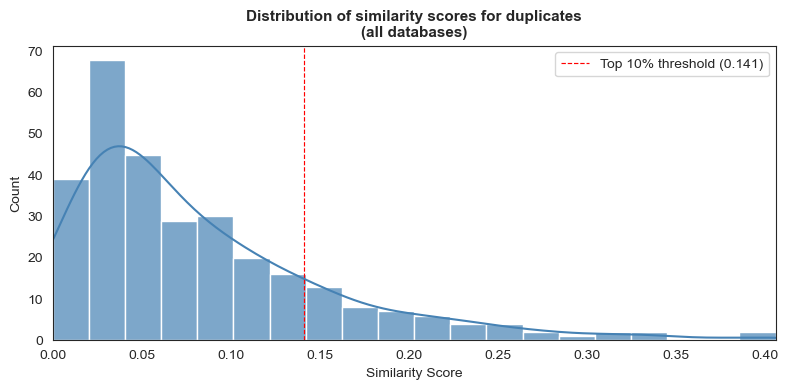


=== Similarity score distribution for 298 duplicates ===
Mean: 0.083
Median: 0.059
Min: 0.000
Max: 0.406
Std Dev: 0.073


In [ ]:
# simple histogram of the distribution of duplicates based on similarity score
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=similarity_dupes,
    x='similarity_score',
    bins=20,
    kde=True,
    color='steelblue', 
    alpha=0.7,
    ax=ax  
)
ax.margins(x=0)
plt.axvline(x=0.141, color='red', linestyle='--', linewidth=0.85, label='Top 10% threshold (0.141)')
plt.title('Distribution of similarity scores for duplicates\n(all databases)', fontsize=11, fontweight='bold')
plt.xlabel('Similarity Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('output/duplicates_similarity_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# summary stats
print(f"\n=== Similarity score distribution for {len(similarity_dupes)} duplicates ===")
print(f"Mean: {similarity_dupes['similarity_score'].mean():.3f}")
print(f"Median: {similarity_dupes['similarity_score'].median():.3f}")
print(f"Min: {similarity_dupes['similarity_score'].min():.3f}")
print(f"Max: {similarity_dupes['similarity_score'].max():.3f}")
print(f"Std Dev: {similarity_dupes['similarity_score'].std():.3f}")

/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_66872/841000106.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats_top10 = df_temp.groupby('score_bin').agg(
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_66872/841000106.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v2800000gn/T/ipykernel_66872/841000106.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
/var/folders/dw/5pyz4zx14ngbnn5q1vb8v28000

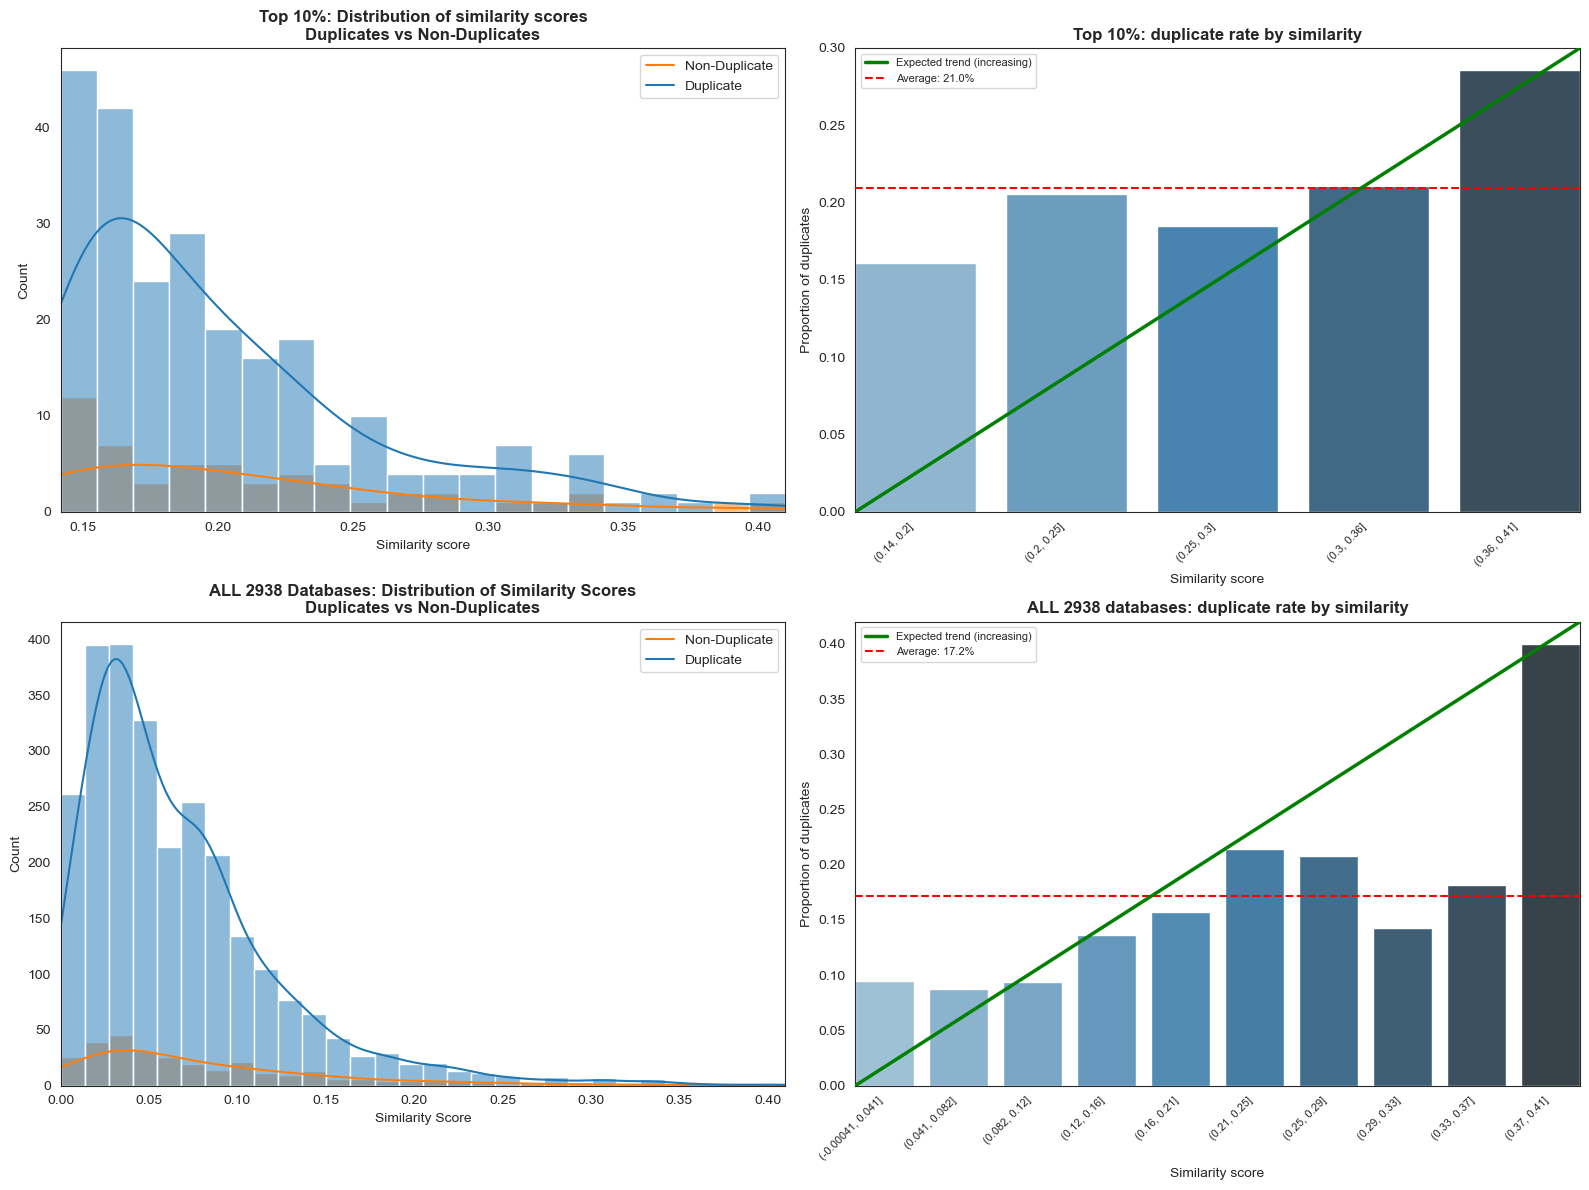


=== Comparison Summary ===

Top 10% (n=294):
  Duplicates: 53 (18.0%)
  Score range: 0.142 - 0.410

ALL 2938 (n=2938):
  Duplicates: 298 (10.1%)
  Score range: 0.000 - 0.410


In [ ]:
# Create 2x2 grid: Top 10% (left) vs ALL (right)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =====================
# TOP 10% PLOTS (from before)
# =====================

# Plot 1A: Distribution for top 10%
sns.histplot(
    data=df_temp,  # this is the top 10% df with _is_duplicate
    x='similarity_score',
    hue='_is_duplicate',
    bins=20,
    alpha=0.5,
    ax=axes[0, 0],
    kde=True
)
axes[0, 0].margins(x=0)
axes[0, 0].set_title('Top 10%: Distribution of similarity scores\nDuplicates vs Non-Duplicates', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Similarity score')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(['Non-Duplicate', 'Duplicate'])

# Plot 1B: Duplicate rate by bin for top 10%
df_temp['score_bin'] = pd.cut(df_temp['similarity_score'], bins=5, precision=2)
bin_stats_top10 = df_temp.groupby('score_bin').agg(
    total_count=('_is_duplicate', 'count'),
    duplicate_rate=('_is_duplicate', 'mean')
).reset_index()
bin_stats_top10['bin_midpoint'] = bin_stats_top10['score_bin'].apply(lambda x: x.mid)

sns.barplot(
    data=bin_stats_top10,
    x='score_bin',
    y='duplicate_rate',
    ax=axes[0, 1],
    palette='Blues_d'
)
axes[0, 1].margins(x=0)
axes[0, 1].plot([0, 1], [0, 1], color='green', linestyle='-', linewidth=2.5, 
                 transform=axes[0, 1].transAxes, label='Expected trend (increasing)', zorder=5)
axes[0, 1].axhline(y=bin_stats_top10['duplicate_rate'].mean(), color='red', linestyle='--', 
                   label=f'Average: {bin_stats_top10["duplicate_rate"].mean():.1%}', zorder=4)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0, 1].set_title('Top 10%: duplicate rate by similarity', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Similarity score')
axes[0, 1].set_ylabel('Proportion of duplicates')
axes[0, 1].legend(fontsize=8)

# =====================
# ALL DATABASES PLOTS
# =====================

# Plot 2A: Distribution for ALL
sns.histplot(
    data=df_all_similarity_dedup,
    x='similarity_score',
    hue='_is_duplicate',
    bins=30,
    alpha=0.5,
    ax=axes[1, 0],
    kde=True
)
axes[1, 0].margins(x=0)
axes[1, 0].set_title('ALL 2938 Databases: Distribution of Similarity Scores\nDuplicates vs Non-Duplicates', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Similarity Score')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(['Non-Duplicate', 'Duplicate'])

# Plot 2B: Duplicate rate by bin for ALL
df_all_similarity_dedup['score_bin'] = pd.cut(df_all_similarity_dedup['similarity_score'], bins=10, precision=2)
bin_stats_all = df_all_similarity_dedup.groupby('score_bin').agg(
    total_count=('_is_duplicate', 'count'),
    duplicate_rate=('_is_duplicate', 'mean')
).reset_index()

sns.barplot(
    data=bin_stats_all,
    x='score_bin',
    y='duplicate_rate',
    ax=axes[1, 1],
    palette='Blues_d'
)
axes[1, 1].margins(x=0)
axes[1, 1].plot([0, 1], [0, 1], color='green', linestyle='-', linewidth=2.5, 
                 transform=axes[1, 1].transAxes, label='Expected trend (increasing)', zorder=5)
axes[1, 1].axhline(y=bin_stats_all['duplicate_rate'].mean(), color='red', linestyle='--', 
                   label=f'Average: {bin_stats_all["duplicate_rate"].mean():.1%}', zorder=4)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1, 1].set_title('ALL 2938 databases: duplicate rate by similarity', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Similarity score')
axes[1, 1].set_ylabel('Proportion of duplicates')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/similarity_scores_comparison_Top10vsAll.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary comparison
print("\n=== Comparison Summary ===")
print(f"\nTop 10% (n={len(df_temp)}):")
print(f"  Duplicates: {df_temp['_is_duplicate'].sum()} ({df_temp['_is_duplicate'].mean():.1%})")
print(f"  Score range: {df_temp['similarity_score'].min():.3f} - {df_temp['similarity_score'].max():.3f}")

print(f"\nALL 2938 (n={len(df_all_similarity_dedup)}):")
print(f"  Duplicates: {df_all_similarity_dedup['_is_duplicate'].sum()} ({df_all_similarity_dedup['_is_duplicate'].mean():.1%})")
print(f"  Score range: {df_all_similarity_dedup['similarity_score'].min():.3f} - {df_all_similarity_dedup['similarity_score'].max():.3f}")